# 02 — Policy Iteration
**Week 4 | Dynamic Programming**

**Policy Iteration** alternates between two steps until the policy stabilises:

1. **Policy Evaluation**: compute V^π for the current policy
2. **Policy Improvement**: greedily update π using V^π

Guaranteed to converge to the optimal policy π* in finite MDPs.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc))
        ns=nr*self.size+nc
        if (nr,nc)==self.goal:      return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits:    return [(1.0,ns,-5.0,False)]
        #if	(nr,nc)==(2,2):		    return	[(1.0,ns,+3.0,False)]
        return [(1.0,ns,-0.1,False)]

env = GridWorld()

In [7]:
def policy_eval(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v; delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < theta: break
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((env.n_states(), env.n_actions()))
    for s in range(env.n_states()):
        Q_s = np.array([sum(p*(r + (0 if d else gamma*V[ns]))
                        for p,ns,r,d in env.transitions(s,a))
                        for a in range(env.n_actions())])
        best_actions = np.where(Q_s == Q_s.max())[0]
        policy[s, best_actions] = 1.0 / len(best_actions)
    return policy

def policy_iteration(env, gamma=0.99):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    policy_history = [policy.argmax(axis=1).copy()]
    V_history = []
    iteration = 0
    while True:
        V = policy_eval(env, policy, gamma)
        V_history.append(V.copy())
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Policy iteration converged in {iteration+1} iterations")
            return policy, V, policy_history, V_history
        policy = new_policy
        policy_history.append(policy.argmax(axis=1).copy())
        iteration += 1

In [8]:
opt_policy, opt_V, pol_hist, V_hist = policy_iteration(env)

Policy iteration converged in 3 iterations


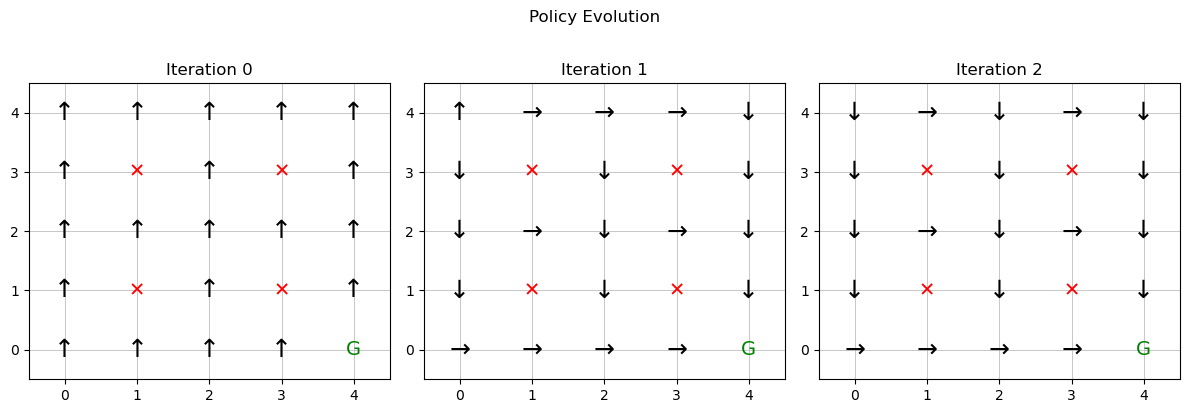

In [9]:
# Show policy evolution
n_iters = len(pol_hist)
fig, axes = plt.subplots(1, n_iters, figsize=(4*n_iters, 4))
if n_iters == 1: axes = [axes]
for ax, (pi, title) in enumerate(zip(pol_hist, [f'Iter {i}' for i in range(n_iters)])):
    axes[ax].set_xlim(-0.5, 4.5); axes[ax].set_ylim(-0.5, 4.5)
    axes[ax].set_xticks(range(5)); axes[ax].set_yticks(range(5))
    axes[ax].grid(True, linewidth=0.5)
    for s in range(25):
        r, c = divmod(s, 5)
        if (r,c) == env.goal:         axes[ax].text(c, 4-r, 'G', ha='center', va='center', fontsize=14, color='green')
        elif (r,c) in env.pits:       axes[ax].text(c, 4-r, '✕', ha='center', va='center', fontsize=14, color='red')
        else:                         axes[ax].text(c, 4-r, env.ACTION_SYMBOLS[pol_hist[ax][s]], ha='center', va='center', fontsize=18)
    axes[ax].set_title(f'Iteration {ax}')
plt.suptitle('Policy Evolution', y=1.02); plt.tight_layout(); plt.show()

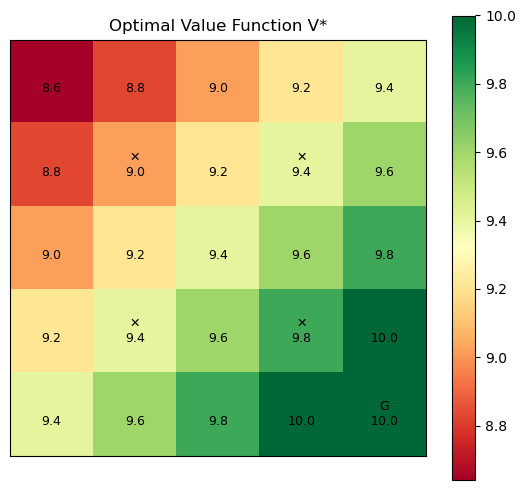

In [10]:
# Final optimal value function
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    ax.text(c, r, f'{label}\n{opt_V[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal Value Function V*'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a 'treasure' cell at (2,2) giving +3 reward (non-terminal). Does the optimal policy change to seek it?
2. Change pits to non-terminal (-5 reward but keep going). How does the policy change?
3. **Challenge**: implement **modified policy iteration** — only do k=5 steps of evaluation per improvement instead of full convergence. Does it still find the optimal policy?

Ans 1 ) Result - Since	entering	(2,2)	pays	+3	every	time	and	never
terminates,	the	policy	oscillates	between	(2,2)	and	a	neighbour:	per
two	steps	it	earns	+3	−	0.1,	giving	V	≈	(3	−	0.1γ)/(1	−	γ²)	≈	145	at
γ=0.99	—	vastly	better	than	the	+10	goal

Ans 2) Whats different from Ans 1 - What	changes	is	the	value	function:	pit	cells	and
their	neighbours	are	much	less	catastrophic,	because	falling	in	no
longer	forfeits	the	+10	goal	—	you	pay	−5	and	keep	walking.	

Ans 3) YES ! - 	it	still	finds	the	optimal	policy	—	usually	needing
a	few	more	outer	iterations,	but	each	outer	iteration	is	dramatically
cheaper

In [11]:
def	policy_eval_k(env,	policy,	gamma=0.99,	k=5):
				V	=	np.zeros(env.n_states())
				for	_	in	range(k):
								V_new	=	np.zeros_like(V)
								for	s	in	range(env.n_states()):
												V_new[s]	=	sum(policy[s,a]	*	sum(p*(r	+	(0	if	d	else	gamma*V[ns]))
																											for	p,ns,r,d	in	env.transitions(s,a))
																											for	a	in	range(env.n_actions()))
								V	=	V_new
				return	V
def	modified_policy_iteration(env,	gamma=0.99,	k=5,	max_outer=200):
				policy	=	np.ones((env.n_states(),	env.n_actions()))	/	env.n_actions()
				for	i	in	range(max_outer):
								V	=	policy_eval_k(env,	policy,	gamma,	k)
								new_policy	=	policy_improvement(env,	V,	gamma)
								if	np.array_equal(new_policy.argmax(1),	policy.argmax(1)):
												print(f"Modified	PI	converged	in	{i+1}	outer	iterations	(k={k})")
												return	new_policy,	V
								policy	=	new_policy
				return	policy,	V
mpi_policy,	mpi_V	=	modified_policy_iteration(env,	k=5)
print("Same	policy	as	full	PI:",	
np.array_equal(mpi_policy.argmax(1),	opt_policy.argmax(1)))

Modified	PI	converged	in	5	outer	iterations	(k=5)
Same	policy	as	full	PI: False
